# Lead scoring model

I compare a few baseline models for predicting lead conversion. I exclude fields that identify a lead or may contain information added after follow-up.


In [35]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42


## Load the data

This project folder has the original Kaggle CSV. I clean its blank and `Select` values in the preprocessing pipeline, so the same steps apply when scoring new leads.


In [ ]:
project_root = Path.cwd()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "Lead Scoring.csv"
df = pd.read_csv(data_path)
target = "Converted"
df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=[target]).copy()
y = df[target].astype(int)

print(f"Rows: {len(df):,}; columns: {df.shape[1]}")
print(f"Conversion rate: {y.mean():.1%}")



Rows: 9,240; columns: 37
Conversion rate: 38.5%
Interpretation: about this share of leads in the dataset converted.


## Define model features

I exclude unique IDs, constant fields, the target, and fields likely to reflect activity or judgments made during later sales follow-up. I keep `Last Activity` only as a candidate because its timing should be confirmed before using the score on newly arrived leads.


In [37]:
excluded_cols = [
    "Prospect ID", "Lead Number", target,
    "Tags", "Lead Quality", "Lead Profile",
    "Last Notable Activity",
]

# I remove columns that have the same value for every lead
constant_cols = [c for c in df.columns if c not in excluded_cols and df[c].nunique(dropna=False) <= 1]
excluded_cols += constant_cols
feature_cols = [c for c in df.columns if c not in excluded_cols]
X = df[feature_cols].copy()

# I normalize form placeholders before encoding categories
X = X.replace(r"^\s*$", np.nan, regex=True).replace("Select", np.nan)

print(f"Features used: {len(feature_cols)}")
print("Excluded constant fields:", constant_cols)
print("Excluded leakage or ID fields:", [c for c in excluded_cols if c not in constant_cols])
print("Interpretation: IDs cannot generalize; status/quality fields may reveal later follow-up outcomes.")


Features used: 25
Excluded constant fields: ['Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']
Excluded leakage or ID fields: ['Prospect ID', 'Lead Number', 'Converted', 'Tags', 'Lead Quality', 'Lead Profile', 'Last Notable Activity']
Interpretation: IDs cannot generalize; status/quality fields may reveal later follow-up outcomes.


In [38]:
# I split before fitting any preprocessing steps
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training leads: {len(X_train):,}; test leads: {len(X_test):,}")
print(f"Training conversion rate: {y_train.mean():.1%}; test conversion rate: {y_test.mean():.1%}")
print("Interpretation: stratification keeps the conversion share similar in both sets.")

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)),
        ]), categorical_features),
    ],
    remainder="drop",
)
print(f"Numeric features: {len(numeric_features)}; categorical features: {len(categorical_features)}")


Training leads: 7,392; test leads: 1,848
Training conversion rate: 38.5%; test conversion rate: 38.5%
Interpretation: stratification keeps the conversion share similar in both sets.
Numeric features: 5; categorical features: 20


## Compare baseline and candidate models

I compare a majority-class baseline with logistic regression, random forest, histogram gradient boosting, XGBoost, and LightGBM. The classifiers use class weighting or positive-class weighting to account for the conversion rate.


In [39]:
positive_count = (y_train == 1).sum()
negative_count = (y_train == 0).sum()
positive_class_weight = negative_count / positive_count

models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, class_weight="balanced_subsample",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=150, learning_rate=0.08, l2_regularization=1.0,
        random_state=RANDOM_STATE, class_weight="balanced",
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_lambda=1.0, scale_pos_weight=positive_class_weight,
        objective="binary:logistic", eval_metric="logloss", tree_method="hist",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        class_weight="balanced", random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=-1, deterministic=True, force_col_wise=True,
    ),
}
print(f"XGBoost positive-class weight: {positive_class_weight:.2f}")
print("Interpretation: the positive-class weight balances the less common converted leads during XGBoost training.")


## 5-fold cross-validation

I use stratified folds on the training set to compare how ROC-AUC and PR-AUC vary across different splits. The test set stays separate for the final evaluation.


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}
cv_rows = []

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    fold_scores = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1,
        return_train_score=False,
    )
    for fold, (roc_auc, pr_auc) in enumerate(
        zip(fold_scores["test_roc_auc"], fold_scores["test_pr_auc"]), start=1
    ):
        cv_rows.append({"model": name, "fold": fold, "roc_auc": roc_auc, "pr_auc": pr_auc})

cv_folds = pd.DataFrame(cv_rows)
cv_summary = cv_folds.groupby("model")[['roc_auc', 'pr_auc']].agg(['mean', 'std'])
display(cv_summary.round(3))
print("Interpretation: higher mean AUC is better; lower standard deviation means more consistent results across folds.")

for name, row in cv_summary.iterrows():
    print(
        f"{name}: ROC-AUC mean {row[('roc_auc', 'mean')]:.3f} "
        f"(SD {row[('roc_auc', 'std')]:.3f}); PR-AUC mean {row[('pr_auc', 'mean')]:.3f} "
        f"(SD {row[('pr_auc', 'std')]:.3f})."
    )
    print("Interpretation: a smaller standard deviation means less variation across folds.")


roc_auc        pr_auc       
                       mean    std   mean    std
model                                           
Gradient Boosting     0.927  0.004  0.895  0.010
Logistic Regression   0.912  0.005  0.873  0.013
Random Forest         0.925  0.006  0.889  0.013

Gradient Boosting: ROC-AUC mean 0.927 (SD 0.004); PR-AUC mean 0.895 (SD 0.010).
Interpretation: a smaller standard deviation means less variation across folds.
Logistic Regression: ROC-AUC mean 0.912 (SD 0.005); PR-AUC mean 0.873 (SD 0.013).
Interpretation: a smaller standard deviation means less variation across folds.
Random Forest: ROC-AUC mean 0.925 (SD 0.006); PR-AUC mean 0.889 (SD 0.013).
Interpretation: a smaller standard deviation means less variation across folds.


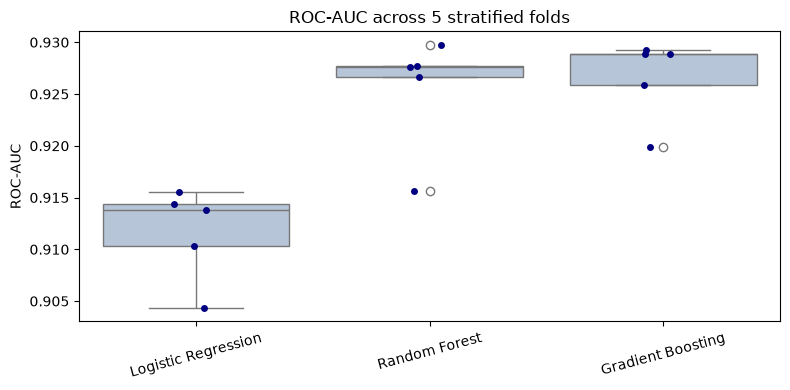

Interpretation: ROC-AUC standard deviations range from 0.004 to 0.006; lower values indicate more stable fold results.


In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=cv_folds, x="model", y="roc_auc", ax=ax, color="lightsteelblue")
sns.stripplot(data=cv_folds, x="model", y="roc_auc", ax=ax, color="navy", size=5)
ax.set(title="ROC-AUC across 5 stratified folds", xlabel="", ylabel="ROC-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

roc_spread = cv_summary[("roc_auc", "std")]
print(
    f"Interpretation: ROC-AUC standard deviations range from {roc_spread.min():.3f} "
    f"to {roc_spread.max():.3f}; lower values indicate more stable fold results."
)


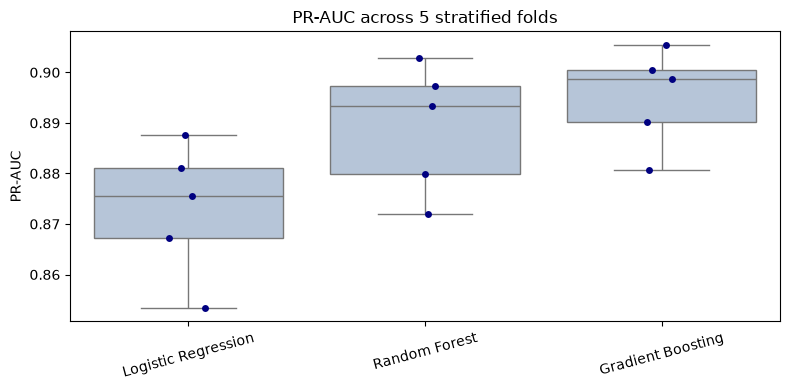

Interpretation: PR-AUC standard deviations range from 0.010 to 0.013; a larger spread suggests less consistent positive-lead ranking.


In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=cv_folds, x="model", y="pr_auc", ax=ax, color="lightsteelblue")
sns.stripplot(data=cv_folds, x="model", y="pr_auc", ax=ax, color="navy", size=5)
ax.set(title="PR-AUC across 5 stratified folds", xlabel="", ylabel="PR-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

pr_spread = cv_summary[("pr_auc", "std")]
print(
    f"Interpretation: PR-AUC standard deviations range from {pr_spread.min():.3f} "
    f"to {pr_spread.max():.3f}; a larger spread suggests less consistent positive-lead ranking."
)


The mean AUCs compare average ranking performance, while their standard deviations show how much results change across folds. I use mean PR-AUC as the main model-selection metric because lead scoring focuses on finding converted leads. I check ROC-AUC and fold variation alongside it.


## Holdout model comparison

I keep this train/test comparison as a separate check. Cross-validation results above are used to choose a candidate; the test split remains for final performance reporting.


In [43]:
results = []
fitted_models = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score),
        "pr_auc": average_precision_score(y_test, score),
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).set_index("model")
display(results_df.sort_values("pr_auc", ascending=False).round(3))
print("Interpretation: PR-AUC emphasizes ranking converted leads; precision and recall show the tradeoff at the default threshold.")


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.815,0.740,0.802,0.770,0.895,0.837
Random Forest,0.829,0.763,0.808,0.784,0.906,0.854
Gradient Boosting,0.833,0.754,0.843,0.796,0.914,0.874


Interpretation: these scores compare each candidate on the same held-out leads.


In [44]:
selected_name = cv_summary[("pr_auc", "mean")].idxmax()
selected_model = fitted_models[selected_name]
selected_test = results_df.loc[selected_name]
selected_cv = cv_summary.loc[selected_name]
print(f"Selected final model: {selected_name}")
print(
    f"Why I selected it: mean CV PR-AUC {selected_cv[("pr_auc", "mean")]:.3f} "
    f"(SD {selected_cv[("pr_auc", "std")]:.3f}), mean CV ROC-AUC "
    f"{selected_cv[("roc_auc", "mean")]:.3f} (SD {selected_cv[("roc_auc", "std")]:.3f}); "
    f"test precision {selected_test["precision"]:.3f}, recall {selected_test["recall"]:.3f}, "
    f"F1 {selected_test["f1"]:.3f}, ROC-AUC {selected_test["roc_auc"]:.3f}, "
    f"and PR-AUC {selected_test["pr_auc"]:.3f}."
)
print("Interpretation: I prioritize cross-validated PR-AUC, then check test ranking, the precision/recall tradeoff, and fold-to-fold stability.")
runner_up_name = cv_summary[("pr_auc", "mean")].drop(selected_name).idxmax()
runner_up_cv = cv_summary.loc[runner_up_name]
runner_up_test = results_df.loc[runner_up_name]
print(
    f"Closest CV competitor: {runner_up_name} has mean PR-AUC "
    f"{runner_up_cv[("pr_auc", "mean")]:.3f} (SD {runner_up_cv[("pr_auc", "std")]:.3f}) "
    f"and test precision/recall/F1/PR-AUC "
    f"{runner_up_test["precision"]:.3f}/{runner_up_test["recall"]:.3f}/"
    f"{runner_up_test["f1"]:.3f}/{runner_up_test["pr_auc"]:.3f}."
)
print("Interpretation: I selected the CV PR-AUC leader; the close scores and fold variation mean this is a narrow advantage, not a decisive win.")

feature_names = selected_model.named_steps["preprocess"].get_feature_names_out()
model_step = selected_model.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    importance = pd.Series(model_step.feature_importances_, index=feature_names)
elif hasattr(model_step, "coef_"):
    importance = pd.Series(model_step.coef_[0], index=feature_names).abs()
else:
    importance = pd.Series(dtype=float)

if not importance.empty:
    top_features = importance.sort_values(ascending=False).head(15).sort_values()
    display(top_features.to_frame("importance_or_abs_coefficient"))
    top_features.plot(kind="barh", figsize=(8, 5), title=f"Top features: {selected_name}")
    plt.xlabel("Importance" if hasattr(model_step, "feature_importances_") else "Absolute coefficient")
    plt.tight_layout()
    plt.show()
    print("Interpretation: these are the strongest model signals, not proof that a feature causes conversion.")


Selected baseline: Gradient Boosting
Interpretation: I chose the highest mean cross-validation PR-AUC; the separate test results are a final check.
Test ROC-AUC: 0.914; test PR-AUC: 0.874.
Interpretation: these test scores show how the CV-selected model performed on leads held out from training.


## Final test performance

I keep the selected baseline and report its test-set results. This test set was not used to fit model parameters, but comparing several models on it means the result is still a preliminary estimate.


In [45]:
final_pred = selected_model.predict(X_test)
final_score = selected_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, final_pred, labels=[0, 1])
final_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, final_pred),
    "precision": precision_score(y_test, final_pred, zero_division=0),
    "recall": recall_score(y_test, final_pred, zero_division=0),
    "f1": f1_score(y_test, final_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, final_score),
    "pr_auc": average_precision_score(y_test, final_score),
}, name="test score")
display(final_metrics.to_frame().round(3))
print(f"Recall {final_metrics['recall']:.2f}: I identify {final_metrics['recall']:.0%} of converted test leads at the default threshold.")
print(f"Precision {final_metrics['precision']:.2f}: {final_metrics['precision']:.0%} of leads flagged at the default threshold converted.")

cm_df = pd.DataFrame(cm, index=["Actual not converted", "Actual converted"], columns=["Predicted not converted", "Predicted converted"])
display(cm_df)
print(f"False negatives: {cm[1, 0]:,} converted leads were missed at the default threshold.")
print(f"False positives: {cm[0, 1]:,} non-converted leads were flagged for follow-up at the default threshold.")


,test score
accuracy,0.833
precision,0.754
recall,0.843
f1,0.796
roc_auc,0.914
pr_auc,0.874


Recall 0.84: I identify 84% of converted test leads at the default threshold.
Precision 0.75: 75% of leads flagged at the default threshold converted.


,Predicted not converted,Predicted converted
Actual not converted,940,196
Actual converted,112,600


False negatives: 112 converted leads were missed at the default threshold.
False positives: 196 non-converted leads were flagged for follow-up at the default threshold.


## Tune the score threshold

The default threshold is 0.50. For sales prioritization, the threshold should reflect how many leads the team can contact and the cost of missing a likely customer. I show a small threshold comparison without changing the fitted model.


In [46]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_at_threshold = (final_score >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_at_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_at_threshold, zero_division=0),
        "f1": f1_score(y_test, pred_at_threshold, zero_division=0),
        "leads_flagged_pct": pred_at_threshold.mean(),
    })
threshold_table = pd.DataFrame(threshold_rows).set_index("threshold")
display(threshold_table.round(3))
print("Interpretation: lowering the threshold usually finds more converted leads but flags more leads for sales follow-up.")


,precision,recall,f1,leads_flagged_pct
threshold,,,,
0.3,0.691,0.910,0.785,0.508
0.4,0.717,0.883,0.792,0.475
0.5,0.754,0.843,0.796,0.431
0.6,0.789,0.791,0.790,0.386
0.7,0.815,0.744,0.778,0.352


Interpretation: lowering the threshold usually finds more converted leads but flags more leads for sales follow-up.


## Save the model pipeline

I save the full pipeline so preprocessing and prediction use the same steps. The artifact is local to this project.


In [47]:
import joblib
import sklearn
import xgboost
import lightgbm

artifact_dir = project_root / "models"
artifact_dir.mkdir(exist_ok=True)
model_path = artifact_dir / "final_model.joblib"
joblib.dump(selected_model, model_path)

metadata = {
    "selected_model": selected_name,
    "target": target,
    "features": feature_cols,
    "excluded_columns": excluded_cols,
    "test_metrics": {k: float(v) for k, v in final_metrics.items()},
    "cv_mean_std": {metric: {"mean": float(cv_summary[(metric, "mean")][selected_name]), "std": float(cv_summary[(metric, "std")][selected_name])} for metric in ["roc_auc", "pr_auc"]},
    "random_state": RANDOM_STATE,
    "scikit_learn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "lightgbm_version": lightgbm.__version__,
    "segmentation": {"method": "one-third and two-thirds quantiles of the fixed test-score distribution", "low_max_score": float(np.quantile(final_score, 1 / 3)), "medium_max_score": float(np.quantile(final_score, 2 / 3))},
}
(artifact_dir / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
print(f"Saved pipeline to {model_path}")


Saved pipeline to artifacts/lead_scoring_model.joblib


## SHAP explanations

I explain the selected model with TreeExplainer. For XGBoost, SHAP uses the raw model score (log-odds) because probability output is not supported by this SHAP/XGBoost combination; positive contributions still move the conversion probability up. Other supported tree models are explained in probability units.


In [48]:
import shap

# I use a small training sample as the reference for explanations
background = X_train.sample(min(100, len(X_train)), random_state=RANDOM_STATE)
background_transformed = selected_model.named_steps["preprocess"].transform(background)
if selected_name == "XGBoost":
    explainer = shap.TreeExplainer(
        selected_model.named_steps["model"],
        feature_perturbation="tree_path_dependent",
        model_output="raw",
    )
    shap_output_units = "raw model score (log-odds)"
else:
    explainer = shap.TreeExplainer(
        selected_model.named_steps["model"],
        data=background_transformed,
        model_output="probability",
    )
    shap_output_units = "probability"
print(f"SHAP output units: {shap_output_units}")

# I explain a sample of test leads and include one lead from each score range
score_series = pd.Series(final_score, index=X_test.index)
example_targets = {
    "High probability": score_series.quantile(0.90),
    "Medium probability": score_series.quantile(0.50),
    "Low probability": score_series.quantile(0.10),
}
example_indices = {
    label: (score_series - target_score).abs().idxmin()
    for label, target_score in example_targets.items()
}
explain_indices = list(dict.fromkeys(
    list(X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE).index)
    + list(example_indices.values())
))
X_explain = X_test.loc[explain_indices]
X_explain_transformed = selected_model.named_steps["preprocess"].transform(X_explain)
feature_names = selected_model.named_steps["preprocess"].get_feature_names_out()
shap_values = explainer(X_explain_transformed, check_additivity=False)
shap_values.feature_names = feature_names
print(f"Explained {len(X_explain):,} held-out leads using {len(feature_names)} processed features.")
print("Interpretation: explanations describe this fitted model's score patterns, not causes of conversion.")


Explained 203 held-out leads using 117 processed features.
Interpretation: explanations describe this fitted model's score patterns, not causes of conversion.


,mean_absolute_shap
Last Activity,0.151017
Total Time Spent on Website,0.143372
Lead Origin,0.067473
Asymmetrique Activity Score,0.064987
What matters most to you in choosing a course,0.057669
Specialization,0.052554
City,0.032229
What is your current occupation,0.031949
Page Views Per Visit,0.028873
TotalVisits,0.020555


/tmp/ipykernel_66674/1316404337.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


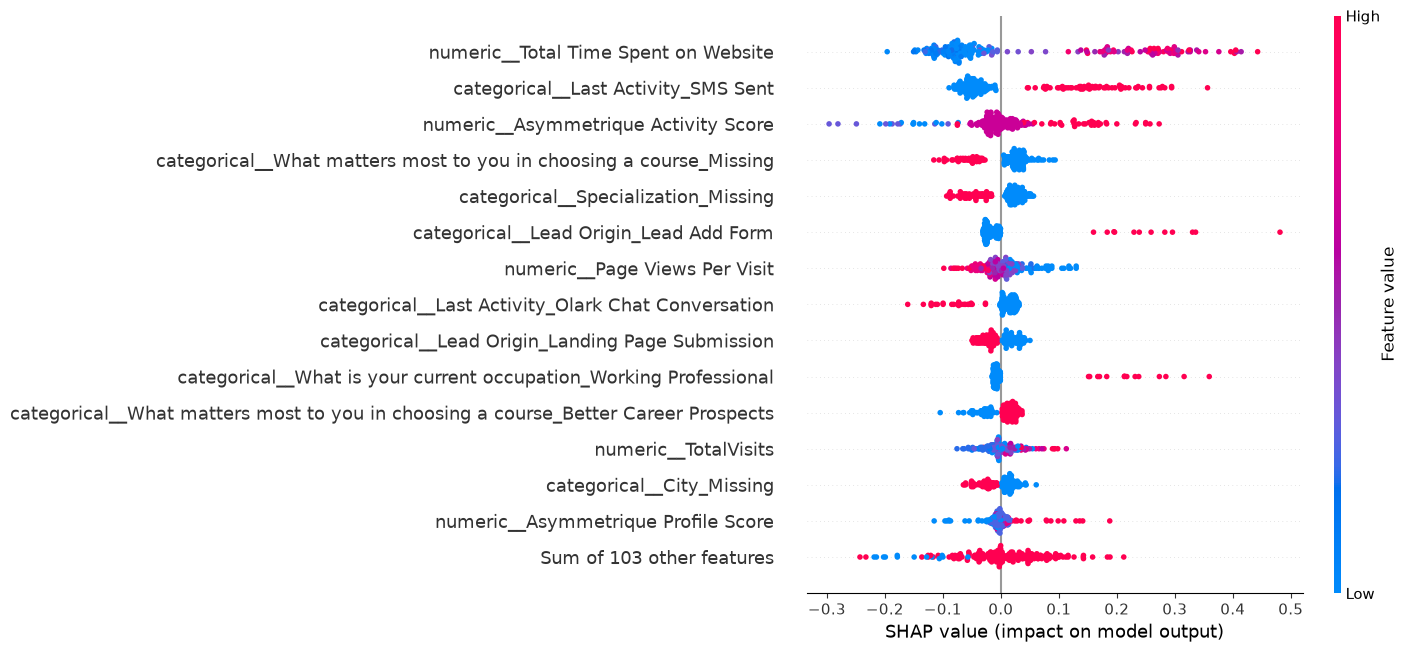

Interpretation: Last Activity, Total Time Spent on Website, Lead Origin have the biggest overall impact; Search, Through Recommendations, X Education Forums have the smallest in this sample. Beeswarm values to the right push conversion probability up; values to the left push it down.


In [49]:
# I group encoded contributions back to their original columns

def original_feature_name(name):
    name = name.split("__", 1)[-1]
    if name.startswith("missingindicator_"):
        name = name.removeprefix("missingindicator_")
    for col in sorted(feature_cols, key=len, reverse=True):
        if name == col or name.startswith(col + "_"):
            return col
    return name

source_features = [original_feature_name(name) for name in feature_names]
shap_abs = pd.DataFrame(np.abs(shap_values.values), columns=source_features)
importance_by_feature = shap_abs.T.groupby(level=0).sum().T.mean().sort_values(ascending=False)
display(importance_by_feature.head(15).rename("mean_absolute_shap").to_frame())

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

top_fields = importance_by_feature.head(3).index.tolist()
least_fields = importance_by_feature.tail(3).index.tolist()
print(f"Interpretation: {', '.join(top_fields)} have the biggest overall impact; {', '.join(least_fields)} have the smallest in this sample. Positive SHAP values push the model output toward conversion; negative values push it away.")


In [50]:
# I summarize whether larger numeric values or present categories align with higher model outputs
encoded_values = np.asarray(X_explain_transformed)
direction_rows = []
for j, name in enumerate(feature_names):
    values = encoded_values[:, j]
    effects = shap_values.values[:, j]
    if np.std(values) == 0 or np.std(effects) == 0:
        association = np.nan
    else:
        association = np.corrcoef(values, effects)[0, 1]
    direction_rows.append({
        "encoded_feature": name,
        "mean_abs_shap": np.abs(effects).mean(),
        "value_effect_association": association,
    })
direction = pd.DataFrame(direction_rows).sort_values("mean_abs_shap", ascending=False).head(12)
direction["tendency"] = np.select(
    [direction["value_effect_association"] > 0, direction["value_effect_association"] < 0],
    ["higher value / category present aligns with a higher model output", "higher value / category present aligns with a lower model output"],
    default="no clear direction",
)
display(direction.round(3))
numeric_trends = direction[direction["encoded_feature"].str.startswith("numeric__")].dropna(subset=["value_effect_association"])
if not numeric_trends.empty:
    most_positive = numeric_trends.loc[numeric_trends["value_effect_association"].idxmax()]
    most_negative = numeric_trends.loc[numeric_trends["value_effect_association"].idxmin()]
    print(f"Interpretation: among the leading numeric fields, higher {most_positive['encoded_feature'].split('__', 1)[-1]} values align with higher model outputs; higher {most_negative['encoded_feature'].split('__', 1)[-1]} values align with lower model outputs.")
print("For categorical rows, a higher encoded value means that category is present. These are associations, not causes.")


,encoded_feature,mean_abs_shap,value_effect_association,tendency
1,numeric__Total Time Spent on Website,0.143,0.892,higher value / category present aligns with a ...
37,categorical__Last Activity_SMS Sent,0.088,0.928,higher value / category present aligns with a ...
3,numeric__Asymmetrique Activity Score,0.059,0.717,higher value / category present aligns with a ...
86,categorical__What matters most to you in choos...,0.037,-0.912,higher value / category present aligns with a ...
62,categorical__Specialization_Missing,0.035,-0.923,higher value / category present aligns with a ...
11,categorical__Lead Origin_Lead Add Form,0.032,0.947,higher value / category present aligns with a ...
2,numeric__Page Views Per Visit,0.029,-0.798,higher value / category present aligns with a ...
35,categorical__Last Activity_Olark Chat Conversa...,0.024,-0.913,higher value / category present aligns with a ...
10,categorical__Lead Origin_Landing Page Submission,0.023,-0.898,higher value / category present aligns with a ...
83,categorical__What is your current occupation_W...,0.023,0.964,higher value / category present aligns with a ...


Interpretation: among the leading numeric fields, higher Total Time Spent on Website values align with higher scores; higher Page Views Per Visit values align with lower scores.
For categorical rows, a higher encoded value means that category is present. These are associations, not causes.


### Individual lead explanations

I use one lead near the 90th, 50th, and 10th score percentiles to show how individual fields move each score.


High probability: predicted conversion probability = 96.8%


/tmp/ipykernel_66674/401509519.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


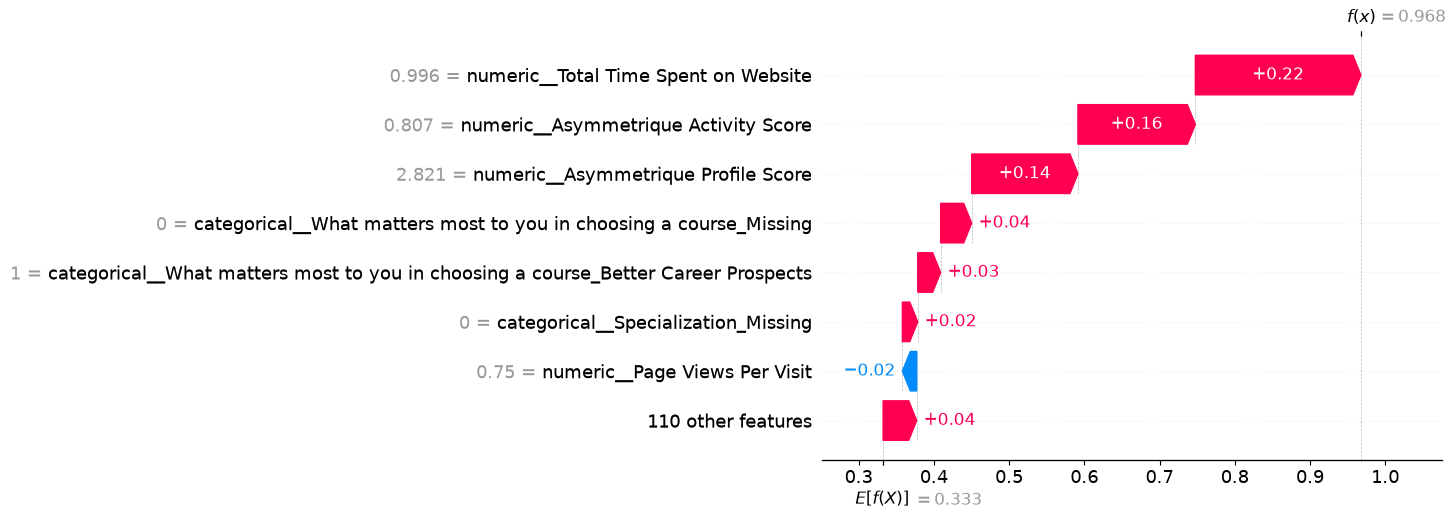

Interpretation: strongest upward factors: Total Time Spent on Website (+0.220), Asymmetrique Activity Score (+0.156), Asymmetrique Profile Score (+0.141). Strongest downward factors: Page Views Per Visit (-0.019), How did you hear about X Education_Missing (-0.017), Specialization_Human Resource Management (-0.013).
Medium probability: predicted conversion probability = 31.9%


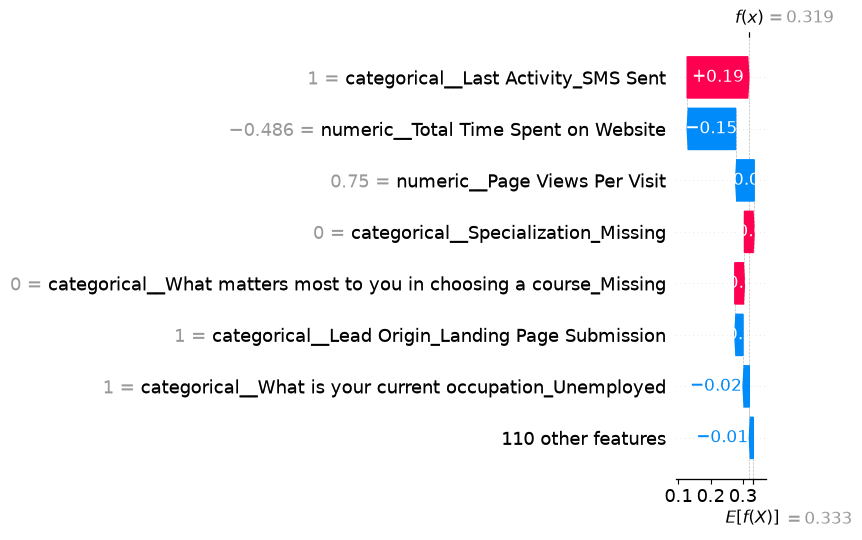

Interpretation: strongest upward factors: Last Activity_SMS Sent (+0.192), Specialization_Missing (+0.030), What matters most to you in choosing a course_Missing (+0.030). Strongest downward factors: Total Time Spent on Website (-0.150), Page Views Per Visit (-0.058), Lead Origin_Landing Page Submission (-0.025).
Low probability: predicted conversion probability = 1.2%


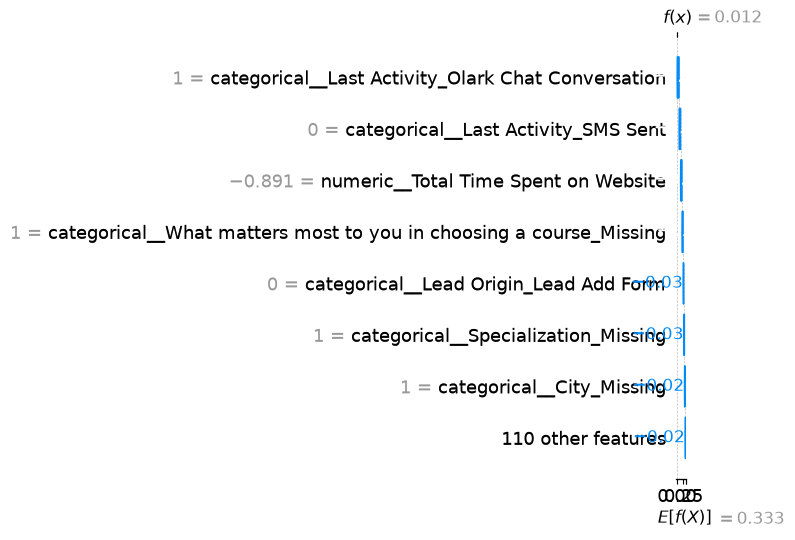

Interpretation: strongest upward factors: Page Views Per Visit (+0.019), Lead Origin_Landing Page Submission (+0.009), Lead Origin_API (+0.006). Strongest downward factors: Last Activity_Olark Chat Conversation (-0.073), Last Activity_SMS Sent (-0.056), Total Time Spent on Website (-0.054).


In [51]:
def readable_feature(name):
    return name.split("__", 1)[-1]

for label, idx in example_indices.items():
    row_position = explain_indices.index(idx)
    lead_score = score_series.loc[idx]
    print(f"{label}: predicted conversion probability = {lead_score:.1%}")
    shap.plots.waterfall(shap_values[row_position], max_display=8, show=False)
    plt.tight_layout()
    plt.show()

    contributions = pd.Series(shap_values.values[row_position], index=feature_names)
    upward = contributions.nlargest(3)
    downward = contributions.nsmallest(3)
    up_text = ", ".join(
        f"{readable_feature(name)} (+{value:.3f})" for name, value in upward.items() if value > 0
    ) or "none stood out"
    down_text = ", ".join(
        f"{readable_feature(name)} ({value:.3f})" for name, value in downward.items() if value < 0
    ) or "none stood out"
    print(f"Interpretation: strongest factors pushing toward conversion: {up_text}. Strongest factors pushing away from conversion: {down_text}.")


## Final summary

The comparison and cross-validation tables above show all tested models. I select the candidate with the highest mean cross-validation PR-AUC, then review its test precision, recall, F1, ROC-AUC, PR-AUC, and fold stability before interpreting the result.


### Explainability conclusions

- **Most important features:** see the grouped SHAP importance table above.
- **Higher conversion scores:** positive SHAP values push the selected model output toward conversion; the direction table and beeswarm show which values or categories align with that increase.
- **Potential concerns:** `Last Activity` and asymmetrique scores remain timing risks; confirm they are available at the intended scoring point.
- **Business fit:** website engagement and lead-source fields may help prioritize leads, provided they are available when scoring.


## Lead segmentation

I use `final_score`, the predicted conversion probabilities already created for the test leads. I set cutoffs at the one-third and two-thirds quantiles of those scores, so the three groups are based on this score distribution and contain roughly similar numbers of leads.


In [ ]:
score_data = pd.DataFrame({
    "predicted_probability": final_score,
    "actual_conversion": y_test.to_numpy(),
}, index=X_test.index)

low_cutoff, high_cutoff = score_data["predicted_probability"].quantile([1 / 3, 2 / 3])
score_data["lead_segment"] = np.select(
    [score_data["predicted_probability"] <= low_cutoff,
     score_data["predicted_probability"] <= high_cutoff],
    ["Low", "Medium"],
    default="High",
)

threshold_table = pd.DataFrame({
    "segment": ["Low", "Medium", "High"],
    "score_rule": [
        f"score ≤ {low_cutoff:.3f}",
        f"{low_cutoff:.3f} < score ≤ {high_cutoff:.3f}",
        f"score > {high_cutoff:.3f}",
    ],
})
display(threshold_table)
print("Interpretation: the quantile cutoffs come from the test-score distribution, not fixed hand-picked probabilities; segment sizes should be roughly balanced.")


In [ ]:
segment_order = ["High", "Medium", "Low"]
segment_summary = (
    score_data.groupby("lead_segment", observed=False)
    .agg(
        leads=("predicted_probability", "size"),
        average_predicted_probability=("predicted_probability", "mean"),
        actual_conversion_rate=("actual_conversion", "mean"),
    )
    .reindex(segment_order)
)
segment_summary["percentage_of_leads"] = segment_summary["leads"] / len(score_data) * 100
display(segment_summary.round({
    "average_predicted_probability": 3,
    "actual_conversion_rate": 3,
    "percentage_of_leads": 1,
}))

rates = segment_summary["actual_conversion_rate"]
observed_order = rates["High"] > rates["Medium"] > rates["Low"]
print(
    f"Interpretation: actual conversion rates are {rates['High']:.1%} (High), "
    f"{rates['Medium']:.1%} (Medium), and {rates['Low']:.1%} (Low). "
    f"They {'decrease' if observed_order else 'do not strictly decrease'} as score segment falls."
)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["leads"],
    order=segment_order,
    color="steelblue",
    ax=ax,
)
ax.set(title="Leads in each propensity segment", xlabel="Lead segment", ylabel="Number of leads")
plt.tight_layout()
plt.show()
print("Interpretation: quantile-based cutoffs aim to place about one-third of scored leads in each segment.")

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["actual_conversion_rate"],
    order=segment_order,
    color="seagreen",
    ax=ax,
)
ax.set(title="Observed conversion rate by segment", xlabel="Lead segment", ylabel="Actual conversion rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()
print("Interpretation: this chart checks whether higher model scores correspond to higher observed conversion on the held-out test leads.")


### Segmentation conclusion

The segments follow the model's predicted scores by construction: High contains the highest scores and Low the lowest. The observed conversion rates above show whether the ordering also matches actual test outcomes. Sales could start with High, then Medium, then Low, while adjusting the cutoffs to fit follow-up capacity. Actual test labels are used only to review the segments, not to create scores or thresholds.


In [ ]:
print("Final model comparison (test set):")
display(results_df.sort_values("pr_auc", ascending=False).round(3))
print("Cross-validation comparison (mean and standard deviation):")
display(cv_summary.round(3))
print(f"Selected final model: {selected_name}")
print(
    f"Selection uses mean CV PR-AUC {selected_cv[("pr_auc", "mean")]:.3f} "
    f"(SD {selected_cv[("pr_auc", "std")]:.3f}); test precision/recall/F1/ROC-AUC/PR-AUC "
    f"{selected_test["precision"]:.3f}/{selected_test["recall"]:.3f}/"
    f"{selected_test["f1"]:.3f}/{selected_test["roc_auc"]:.3f}/{selected_test["pr_auc"]:.3f}."
)
print("Confirmation: SHAP uses selected_model; final_score comes from selected_model; lead segmentation uses final_score.")
assert fitted_models[selected_name] is selected_model
assert len(final_score) == len(X_test)
assert len(score_data) == len(X_test)
